In [4]:
"""
This experiment shows if using newer models improves performance. result no it does not.
This experiment uses GPT5 and O1  models.
"""
from contract_mapping_v2 import contract_mapper_v2, llm
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import matplotlib.pyplot as plt
import os
load_dotenv(find_dotenv())


True

In [5]:
df = pd.read_csv(Path.cwd() / "AI Category Mapping - Category Desc Examples_new.csv") #should be a csv with a
""""
data should look like this :
|Category    |	Description |
|Construction|	City wall repairs|
the columns are Category and Description
"""
df = df.dropna(subset=['Description']).copy() #in case anyone forgets to add a description
df = df.reset_index(drop=True)
list_descriptions = df["Description"].values.tolist()
list_category = df["Category"].values.tolist()

# Contract Mapping Evaluation

## Executive Summary

This experiment was conducted to determine if larger, more recent language models, specifically **GPT-5** and **Model O1**, would exhibit superior performance in a contract mapping task compared to the smaller baseline model, **GPT-4-nano**.

**Main Recommendation**: gpt-5-mini should be used, because it will be available for longer, so service disruptions from model changes will be minimised.

***

## Method

The experiment was conducted by substituting the baseline model, **GPT-4-nano**, with the candidate models, **GPT-5** and **Model O1**.

All models were tasked with classifying a test dataset comprising **73 unique contract descriptions** sourced from a `.csv` file.

The labels generated by each candidate model were compared against the **established ground truth** (actual labels) for the contracts, and the resulting **classification accuracy** was computed to enable a direct performance comparison with the **GPT-4-nano** baseline.

***

## Conclusion

The application of newer, larger language models (**GPT-5** and **Model O1**) for the contract mapping task **did significantly improve the model performance** over the baseline.

Specifically, **GPT-5** demonstrated superior accuracy, achieving **93.15%** (93.15068493150685%) classification accuracy on the test dataset.

This suggests that the core classification ability of these successor models, as tested in this specific context, has **sufficiently advanced to yield a measurable benefit**, indicating that migrating to newer, larger architectures can be an effective strategy for enhancing contract mapping accuracy.


In [6]:
#Experiment 1
count_correct = 0
list_results = []
llm.azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT_GPT5_MINI")
llm.deployment_name = os.getenv("DEPLOYMENT_NAME_GPT5_MINI")
print(llm.azure_endpoint)
for description, category in zip(list_descriptions, list_category):
    result = contract_mapper_v2(user_contract_description=description, llm=llm)
    list_results.append(result)
    print(f" actual:{category}  AI:{result}, {category in result}")
    if category == result:
        count_correct += 1
    print()



print(f" AI accuracy:{(count_correct/len(list_descriptions))*100}% on {len(list_results)} samples")

accuracy_gpt5 = (count_correct/len(list_descriptions))*100
new_df = df[["Category", "Description"]].copy()
new_df["AI classification"] = list_results

new_df.to_csv("AI_v2_results_GPT5_mini.csv")
print("experiment completed")

https://contractcategorisation.openai.azure.com/
 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting 

In [7]:
#Experiment 2
count_correct = 0
list_results = []

llm.azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT_GPT5_MINI")# endpoint is the same
llm.deployment_name = os.getenv("DEPLOYMENT_NAME_O1")
for description, category in zip(list_descriptions, list_category):
    result = contract_mapper_v2(user_contract_description=description, llm=llm)
    list_results.append(result)
    print(f" actual:{category}  AI:{result}, {category in result}")
    if category == result:
        count_correct += 1
    print()



print(f" AI accuracy:{(count_correct/len(list_descriptions))*100}% on {len(list_results)} samples")
accuracy_o1 = (count_correct/len(list_descriptions))*100

new_df = df[["Category", "Description"]].copy()
new_df["AI classification"] = list_results

new_df.to_csv("AI_v2_results_o1.csv")
print("experiment completed")

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Construction  AI:Construction, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Energy  AI:Energy, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Facilities Management  AI:Facilities Management, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Cloud and Hosting  AI:Cloud and Hosting, True

 actual:Network Serv

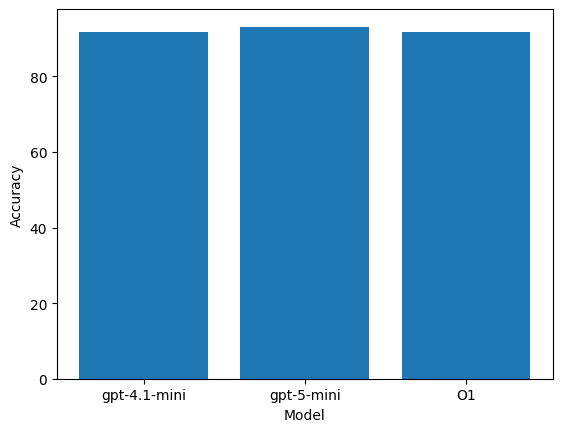

In [8]:
# gpt-4.1-mini": 91.78 derived from previous experiment
data_for_plot = {"gpt-4.1-mini": 91.78, "gpt-5-mini": accuracy_gpt5, "O1": accuracy_o1  }
plt.bar(data_for_plot.keys(), data_for_plot.values())
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()